# COMP9444 Project 005 — Shared Train/Validation Split

This notebook creates one deterministic and reusable split manifest for all segmentation models.

**Output file created in the current folder**

```text
uecfoodpix_split_train3000_val500_seed9444.json
```

The JSON file contains:

- 3000 training image IDs;
- 500 validation image IDs;
- split parameters and dataset paths;
- dominant-class distributions for both subsets.


## 1. Configuration

The expected project structure is:

```text
current_folder/
├── Create_Shared_Train_Val_Split.ipynb
├── dataset/
│   ├── train9000.txt
│   └── UECFoodPIX/
│       └── train/
│           ├── img/
│           └── mask/
```

Change only `DATA_ROOT` when the dataset is stored elsewhere.


In [4]:
from pathlib import Path

# The folder containing this notebook is treated as the project root.
PROJECT_ROOT = Path.cwd()

# Change this line only if the dataset is stored elsewhere.
DATA_ROOT = PROJECT_ROOT / "UECFOODPIX" / "data"

TRAIN_SIZE = 3000
VAL_SIZE = 500
SEED = 9444

# UECFoodPix: 102 food classes + background class 0.
NUM_OUTPUT_CLASSES = 103

# The single reusable split file will be written to the current folder.
OUTPUT_FILE = (
    PROJECT_ROOT
    / f"uecfoodpix_split_train{TRAIN_SIZE}_val{VAL_SIZE}_seed{SEED}.json"
)

# Set to True only when intentionally regenerating the split.
FORCE_RECREATE = False

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATA_ROOT)
print("Output file  :", OUTPUT_FILE)


Project root : f:\Class\1 unsw\COMP 9444 Neural Networks and Deep Learning\GP\Group Project\9444
Dataset root : f:\Class\1 unsw\COMP 9444 Neural Networks and Deep Learning\GP\Group Project\9444\UECFOODPIX\data
Output file  : f:\Class\1 unsw\COMP 9444 Neural Networks and Deep Learning\GP\Group Project\9444\uecfoodpix_split_train3000_val500_seed9444.json


## 2. Imports and Reproducibility

In [5]:
from collections import Counter, defaultdict
from datetime import datetime, timezone
import hashlib
import json
import os
import random
from typing import Dict, Iterable, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm.auto import tqdm


## 3. Dataset Validation

This section verifies that the official training list and the corresponding images and masks exist before creating the split.


In [6]:
TRAIN_LIST_FILE = DATA_ROOT / "train9000.txt"
TRAIN_IMAGE_DIR = DATA_ROOT / "UECFoodPIX" / "train" / "img"
TRAIN_MASK_DIR = DATA_ROOT / "UECFoodPIX" / "train" / "mask"


def read_id_file(path: Path) -> List[str]:
    """Read non-empty sample IDs while preserving leading zeros."""
    if not path.is_file():
        raise FileNotFoundError(f"ID list not found: {path}")

    ids = [
        line.strip()
        for line in path.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]

    if not ids:
        raise ValueError(f"No sample IDs were found in: {path}")

    duplicate_ids = [
        sample_id
        for sample_id, count in Counter(ids).items()
        if count > 1
    ]
    if duplicate_ids:
        preview = duplicate_ids[:10]
        raise ValueError(
            f"The official training list contains duplicate IDs. "
            f"Examples: {preview}"
        )

    return ids


def validate_dataset_files(
    sample_ids: Sequence[str],
    image_dir: Path,
    mask_dir: Path,
) -> None:
    """Check that every listed image and mask exists."""
    if not image_dir.is_dir():
        raise FileNotFoundError(f"Training image directory not found: {image_dir}")
    if not mask_dir.is_dir():
        raise FileNotFoundError(f"Training mask directory not found: {mask_dir}")

    missing_images = []
    missing_masks = []

    for sample_id in tqdm(sample_ids, desc="Checking dataset files"):
        image_path = image_dir / f"{sample_id}.jpg"
        mask_path = mask_dir / f"{sample_id}.png"

        if not image_path.is_file():
            missing_images.append(str(image_path))
        if not mask_path.is_file():
            missing_masks.append(str(mask_path))

    if missing_images or missing_masks:
        message = [
            "The dataset is incomplete.",
            f"Missing images: {len(missing_images)}",
            f"Missing masks : {len(missing_masks)}",
        ]
        if missing_images:
            message.append(f"First missing image: {missing_images[0]}")
        if missing_masks:
            message.append(f"First missing mask: {missing_masks[0]}")
        raise FileNotFoundError("\n".join(message))

    print(f"Validated {len(sample_ids)} image–mask pairs.")


all_train_ids = read_id_file(TRAIN_LIST_FILE)

if TRAIN_SIZE + VAL_SIZE > len(all_train_ids):
    raise ValueError(
        f"Requested {TRAIN_SIZE + VAL_SIZE} samples, but only "
        f"{len(all_train_ids)} official training IDs are available."
    )

validate_dataset_files(
    sample_ids=all_train_ids,
    image_dir=TRAIN_IMAGE_DIR,
    mask_dir=TRAIN_MASK_DIR,
)

print("Official training IDs:", len(all_train_ids))


Checking dataset files:   0%|          | 0/9000 [00:00<?, ?it/s]

Checking dataset files: 100%|██████████| 9000/9000 [00:01<00:00, 5429.99it/s]

Validated 9000 image–mask pairs.
Official training IDs: 9000


## 4. Proportional Split Functions

Each image is assigned to its **dominant foreground food class**, defined as the non-background class occupying the largest number of pixels in its mask.

The procedure is identical to the split logic used in the existing DenseNet121 and EfficientNet-B0 baseline notebooks:

1. sample 3000 training images proportionally using seed `9444`;
2. remove those IDs from the candidate pool;
3. sample 500 validation images proportionally from the remaining IDs using seed `9445`;
4. verify that the two subsets do not overlap.


In [7]:
def dominant_foreground_class(
    mask_path: Path,
    num_output_classes: int = NUM_OUTPUT_CLASSES,
) -> int:
    """
    Return the foreground class with the largest pixel count.

    Class 0 is background and is excluded from the dominant-class decision.
    A completely empty foreground mask is assigned class 0.
    """
    with Image.open(mask_path) as mask_image:
        mask = np.asarray(
            mask_image.getchannel("R"),
            dtype=np.int64,
        )

    if mask.size == 0:
        raise ValueError(f"Empty mask array: {mask_path}")

    minimum_label = int(mask.min())
    maximum_label = int(mask.max())
    if minimum_label < 0 or maximum_label >= num_output_classes:
        raise ValueError(
            f"Mask {mask_path} contains labels outside "
            f"[0, {num_output_classes - 1}]: "
            f"min={minimum_label}, max={maximum_label}"
        )

    counts = np.bincount(
        mask.ravel(),
        minlength=num_output_classes,
    )
    counts[0] = 0

    if counts.sum() == 0:
        return 0

    return int(counts.argmax())


def proportional_sample(
    candidate_ids: Sequence[str],
    labels: Dict[str, int],
    sample_size: int,
    seed: int,
) -> List[str]:
    """
    Sample IDs proportionally to their dominant-class distribution.

    Largest-remainder allocation is used so the final number of selected
    samples is exactly `sample_size`.
    """
    if sample_size < 1:
        raise ValueError("sample_size must be positive")
    if sample_size > len(candidate_ids):
        raise ValueError(
            f"Cannot sample {sample_size} IDs from "
            f"{len(candidate_ids)} candidates."
        )

    groups: Dict[int, List[str]] = defaultdict(list)
    for sample_id in candidate_ids:
        if sample_id not in labels:
            raise KeyError(f"Missing dominant-class label for ID: {sample_id}")
        groups[labels[sample_id]].append(sample_id)

    total_candidates = len(candidate_ids)

    raw_quotas = {
        label: sample_size * len(group) / total_candidates
        for label, group in groups.items()
    }
    quotas = {
        label: int(raw_quota)
        for label, raw_quota in raw_quotas.items()
    }

    unassigned = sample_size - sum(quotas.values())

    allocation_order = sorted(
        groups,
        key=lambda label: (
            raw_quotas[label] - quotas[label],
            len(groups[label]),
            -label,
        ),
        reverse=True,
    )

    for label in allocation_order[:unassigned]:
        quotas[label] += 1

    rng = random.Random(seed)
    selected_ids: List[str] = []

    for label in sorted(groups):
        group = sorted(groups[label])
        rng.shuffle(group)

        quota = quotas[label]
        if quota > len(group):
            raise RuntimeError(
                f"Quota {quota} exceeds group size {len(group)} "
                f"for class {label}."
            )

        selected_ids.extend(group[:quota])

    rng.shuffle(selected_ids)

    if len(selected_ids) != sample_size:
        raise RuntimeError(
            f"Expected {sample_size} selected IDs, "
            f"but obtained {len(selected_ids)}."
        )
    if len(set(selected_ids)) != len(selected_ids):
        raise RuntimeError("The proportional sample contains duplicate IDs.")

    return selected_ids


def distribution_for(
    sample_ids: Iterable[str],
    labels: Dict[str, int],
    num_output_classes: int = NUM_OUTPUT_CLASSES,
) -> Dict[str, int]:
    """Return a JSON-compatible dominant-class count dictionary."""
    counts = Counter(labels[sample_id] for sample_id in sample_ids)
    return {
        str(class_id): int(counts.get(class_id, 0))
        for class_id in range(num_output_classes)
    }


def ids_sha256(sample_ids: Sequence[str]) -> str:
    """Create a compact fingerprint for an ordered ID list."""
    payload = "\n".join(sample_ids).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


## 5. Create or Load the Shared Split File

When the JSON file already exists, it is loaded and validated instead of being regenerated. This guarantees that every baseline uses exactly the same IDs.


In [8]:
def validate_loaded_manifest(
    manifest: dict,
    expected_train_size: int,
    expected_val_size: int,
    expected_seed: int,
) -> Tuple[List[str], List[str]]:
    """Validate a previously saved split manifest."""
    required_keys = {
        "train_ids",
        "val_ids",
        "train_size",
        "val_size",
        "seed",
        "num_output_classes",
    }
    missing_keys = required_keys - set(manifest)
    if missing_keys:
        raise ValueError(
            f"Saved split file is missing keys: {sorted(missing_keys)}"
        )

    train_ids = [str(x) for x in manifest["train_ids"]]
    val_ids = [str(x) for x in manifest["val_ids"]]

    if manifest["train_size"] != expected_train_size:
        raise ValueError(
            f"Saved train_size={manifest['train_size']} does not match "
            f"requested train_size={expected_train_size}."
        )
    if manifest["val_size"] != expected_val_size:
        raise ValueError(
            f"Saved val_size={manifest['val_size']} does not match "
            f"requested val_size={expected_val_size}."
        )
    if manifest["seed"] != expected_seed:
        raise ValueError(
            f"Saved seed={manifest['seed']} does not match "
            f"requested seed={expected_seed}."
        )
    if manifest["num_output_classes"] != NUM_OUTPUT_CLASSES:
        raise ValueError(
            "Saved num_output_classes does not match the current setting."
        )

    if len(train_ids) != expected_train_size:
        raise ValueError("Saved training split has an unexpected size.")
    if len(val_ids) != expected_val_size:
        raise ValueError("Saved validation split has an unexpected size.")
    if len(set(train_ids)) != len(train_ids):
        raise ValueError("Saved training IDs contain duplicates.")
    if len(set(val_ids)) != len(val_ids):
        raise ValueError("Saved validation IDs contain duplicates.")
    if set(train_ids) & set(val_ids):
        raise ValueError("Saved training and validation IDs overlap.")

    official_id_set = set(all_train_ids)
    unknown_train_ids = set(train_ids) - official_id_set
    unknown_val_ids = set(val_ids) - official_id_set
    if unknown_train_ids or unknown_val_ids:
        raise ValueError(
            "The saved split contains IDs that are absent from train9000.txt."
        )

    return train_ids, val_ids


def create_split_manifest() -> dict:
    """Scan masks, create the deterministic split, and return its manifest."""
    print("Scanning masks to determine dominant foreground classes...")

    dominant_labels: Dict[str, int] = {}
    for sample_id in tqdm(all_train_ids, desc="Reading training masks"):
        mask_path = TRAIN_MASK_DIR / f"{sample_id}.png"
        dominant_labels[sample_id] = dominant_foreground_class(mask_path)

    train_ids = proportional_sample(
        candidate_ids=all_train_ids,
        labels=dominant_labels,
        sample_size=TRAIN_SIZE,
        seed=SEED,
    )

    train_id_set = set(train_ids)
    remaining_ids = [
        sample_id
        for sample_id in all_train_ids
        if sample_id not in train_id_set
    ]

    val_ids = proportional_sample(
        candidate_ids=remaining_ids,
        labels=dominant_labels,
        sample_size=VAL_SIZE,
        seed=SEED + 1,
    )

    if set(train_ids) & set(val_ids):
        raise RuntimeError("Training and validation splits overlap.")

    manifest = {
        "format_version": 1,
        "dataset_name": "UECFoodPixComplete",
        "source_train_list": str(TRAIN_LIST_FILE.resolve()),
        "source_train_image_dir": str(TRAIN_IMAGE_DIR.resolve()),
        "source_train_mask_dir": str(TRAIN_MASK_DIR.resolve()),
        "official_training_pool_size": len(all_train_ids),
        "train_size": TRAIN_SIZE,
        "val_size": VAL_SIZE,
        "seed": SEED,
        "validation_seed": SEED + 1,
        "num_food_classes": NUM_OUTPUT_CLASSES - 1,
        "num_output_classes": NUM_OUTPUT_CLASSES,
        "stratification": "dominant_foreground_class",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "train_ids_sha256": ids_sha256(train_ids),
        "val_ids_sha256": ids_sha256(val_ids),
        "train_dominant_class_distribution": distribution_for(
            train_ids,
            dominant_labels,
        ),
        "val_dominant_class_distribution": distribution_for(
            val_ids,
            dominant_labels,
        ),
        "train_ids": train_ids,
        "val_ids": val_ids,
    }

    return manifest


if OUTPUT_FILE.exists() and not FORCE_RECREATE:
    print(f"Loading existing split file: {OUTPUT_FILE}")
    manifest = json.loads(OUTPUT_FILE.read_text(encoding="utf-8"))
else:
    manifest = create_split_manifest()

    temporary_file = OUTPUT_FILE.with_suffix(
        OUTPUT_FILE.suffix + ".tmp"
    )
    temporary_file.write_text(
        json.dumps(manifest, indent=2, ensure_ascii=False) + "\n",
        encoding="utf-8",
    )
    os.replace(temporary_file, OUTPUT_FILE)
    print(f"Created split file: {OUTPUT_FILE}")

train_ids, val_ids = validate_loaded_manifest(
    manifest=manifest,
    expected_train_size=TRAIN_SIZE,
    expected_val_size=VAL_SIZE,
    expected_seed=SEED,
)

print()
print("Training images          :", len(train_ids))
print("Validation images        :", len(val_ids))
print("Train/validation overlap :", len(set(train_ids) & set(val_ids)))
print("Unused official train IDs:", len(all_train_ids) - len(train_ids) - len(val_ids))
print("Shared split file        :", OUTPUT_FILE)


Scanning masks to determine dominant foreground classes...


Reading training masks: 100%|██████████| 9000/9000 [00:16<00:00, 549.03it/s]

Created split file: f:\Class\1 unsw\COMP 9444 Neural Networks and Deep Learning\GP\Group Project\9444\uecfoodpix_split_train3000_val500_seed9444.json

Training images          : 3000
Validation images        : 500
Train/validation overlap : 0
Unused official train IDs: 5500
Shared split file        : f:\Class\1 unsw\COMP 9444 Neural Networks and Deep Learning\GP\Group Project\9444\uecfoodpix_split_train3000_val500_seed9444.json


## 6. Verify the Proportional Class Distribution

This chart is a diagnostic only. It compares the dominant-class distributions after normalising each subset by its own size.


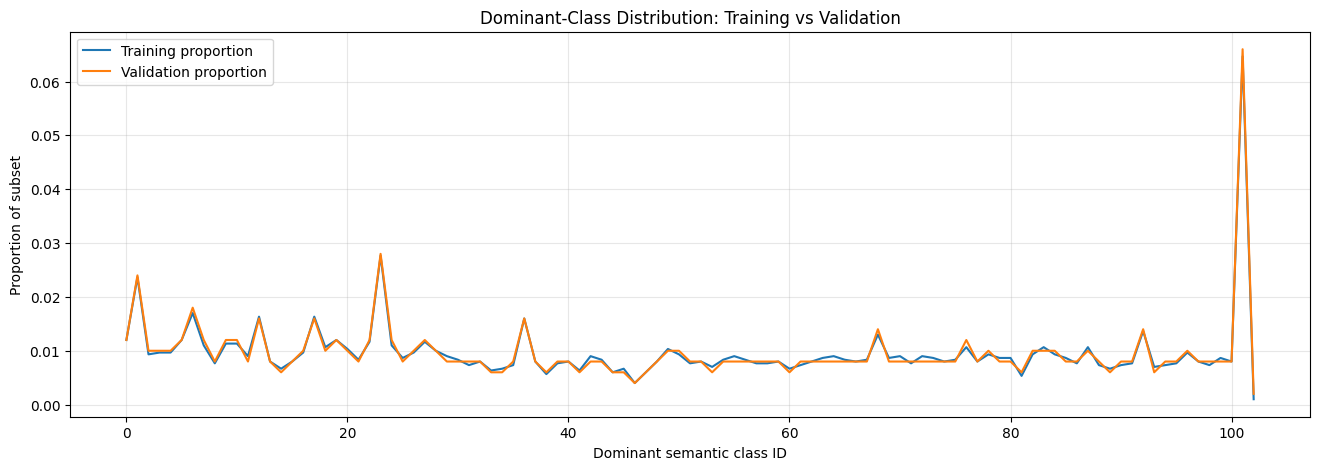

Mean absolute proportional difference: 0.000472
Maximum absolute proportional difference: 0.001333


In [9]:
train_distribution = np.array([
    manifest["train_dominant_class_distribution"][str(class_id)]
    for class_id in range(NUM_OUTPUT_CLASSES)
])
val_distribution = np.array([
    manifest["val_dominant_class_distribution"][str(class_id)]
    for class_id in range(NUM_OUTPUT_CLASSES)
])

train_proportion = train_distribution / train_distribution.sum()
val_proportion = val_distribution / val_distribution.sum()

class_ids = np.arange(NUM_OUTPUT_CLASSES)

plt.figure(figsize=(16, 5))
plt.plot(
    class_ids,
    train_proportion,
    label="Training proportion",
)
plt.plot(
    class_ids,
    val_proportion,
    label="Validation proportion",
)
plt.xlabel("Dominant semantic class ID")
plt.ylabel("Proportion of subset")
plt.title("Dominant-Class Distribution: Training vs Validation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

absolute_difference = np.abs(train_proportion - val_proportion)

print(
    "Mean absolute proportional difference:",
    f"{absolute_difference.mean():.6f}",
)
print(
    "Maximum absolute proportional difference:",
    f"{absolute_difference.max():.6f}",
)


## 7. Reuse the Split in Every Model Notebook

Place the generated JSON file in the same folder as the model notebooks. Replace the previous split-generation section with the following small loading cell:

```python
from pathlib import Path
import json

SPLIT_FILE = Path.cwd() / "uecfoodpix_split_train3000_val500_seed9444.json"
split_manifest = json.loads(SPLIT_FILE.read_text(encoding="utf-8"))

train_ids = split_manifest["train_ids"]
val_ids = split_manifest["val_ids"]

assert len(train_ids) == 3000
assert len(val_ids) == 500
assert not (set(train_ids) & set(val_ids))
```

The model-specific dataset and training code can then use `train_ids` and `val_ids` directly.


In [10]:
# Optional final preview
print("First 10 training IDs  :", train_ids[:10])
print("First 10 validation IDs:", val_ids[:10])

print()
print("Copy this path into the other notebooks if needed:")
print(OUTPUT_FILE.resolve())


First 10 training IDs  : ['8254', '4934', '3544', '9106', '15375', '8572', '6411', '563', '13760', '3800']
First 10 validation IDs: ['12628', '348', '1977', '1572', '11640', '1879', '8996', '4509', '11630', '16493']

Copy this path into the other notebooks if needed:
F:\Class\1 unsw\COMP 9444 Neural Networks and Deep Learning\GP\Group Project\9444\uecfoodpix_split_train3000_val500_seed9444.json
